In [14]:
# 🛠️ Advanced imports for production ML

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments

# 🧰 Sklearn libraries - expanded for advanced ML workflows
from sklearn.datasets import fetch_california_housing  # Real-world dataset
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment


In [15]:
class Config:
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  
    CV_FOLDS = 5
    N_JOBS = -1  
    
    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"
    
    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    
config = Config()

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

tracking_path = os.path.abspath(config.EXPERIMENT_DIR)
mlflow.set_tracking_uri(tracking_path)

experiment_name = "california_housing_advanced"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location=('c:\\Users\\LENOVO\\sair\\mohamed\\SAIR_Jr\\1_Regression\\Regression Capstone '
 'Projects\\MO\\experiments/301696268783039579'), creation_time=1791213455707, effective_trace_archival_retention=None, experiment_id='301696268783039579', last_update_time=1791213455707, lifecycle_stage='active', name='california_housing_advanced', tags={}, trace_location=None, workspace='default'>

In [16]:

import kagglehub


path = kagglehub.dataset_download("amjadzhour/car-price-prediction")
files = os.listdir(path)


csv_file = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)
df = pd.read_csv(file_path)


X_df = df.drop(columns=['Price'])

X = X_df.values                        
y = df['Price'].values                
feature_names = X_df.columns.tolist()  

In [17]:
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [18]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


In [19]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

In [20]:
df.dtypes

Make                str
Model               str
Year              int64
Engine Size     float64
Mileage           int64
Fuel Type           str
Transmission        str
Price           float64
dtype: object

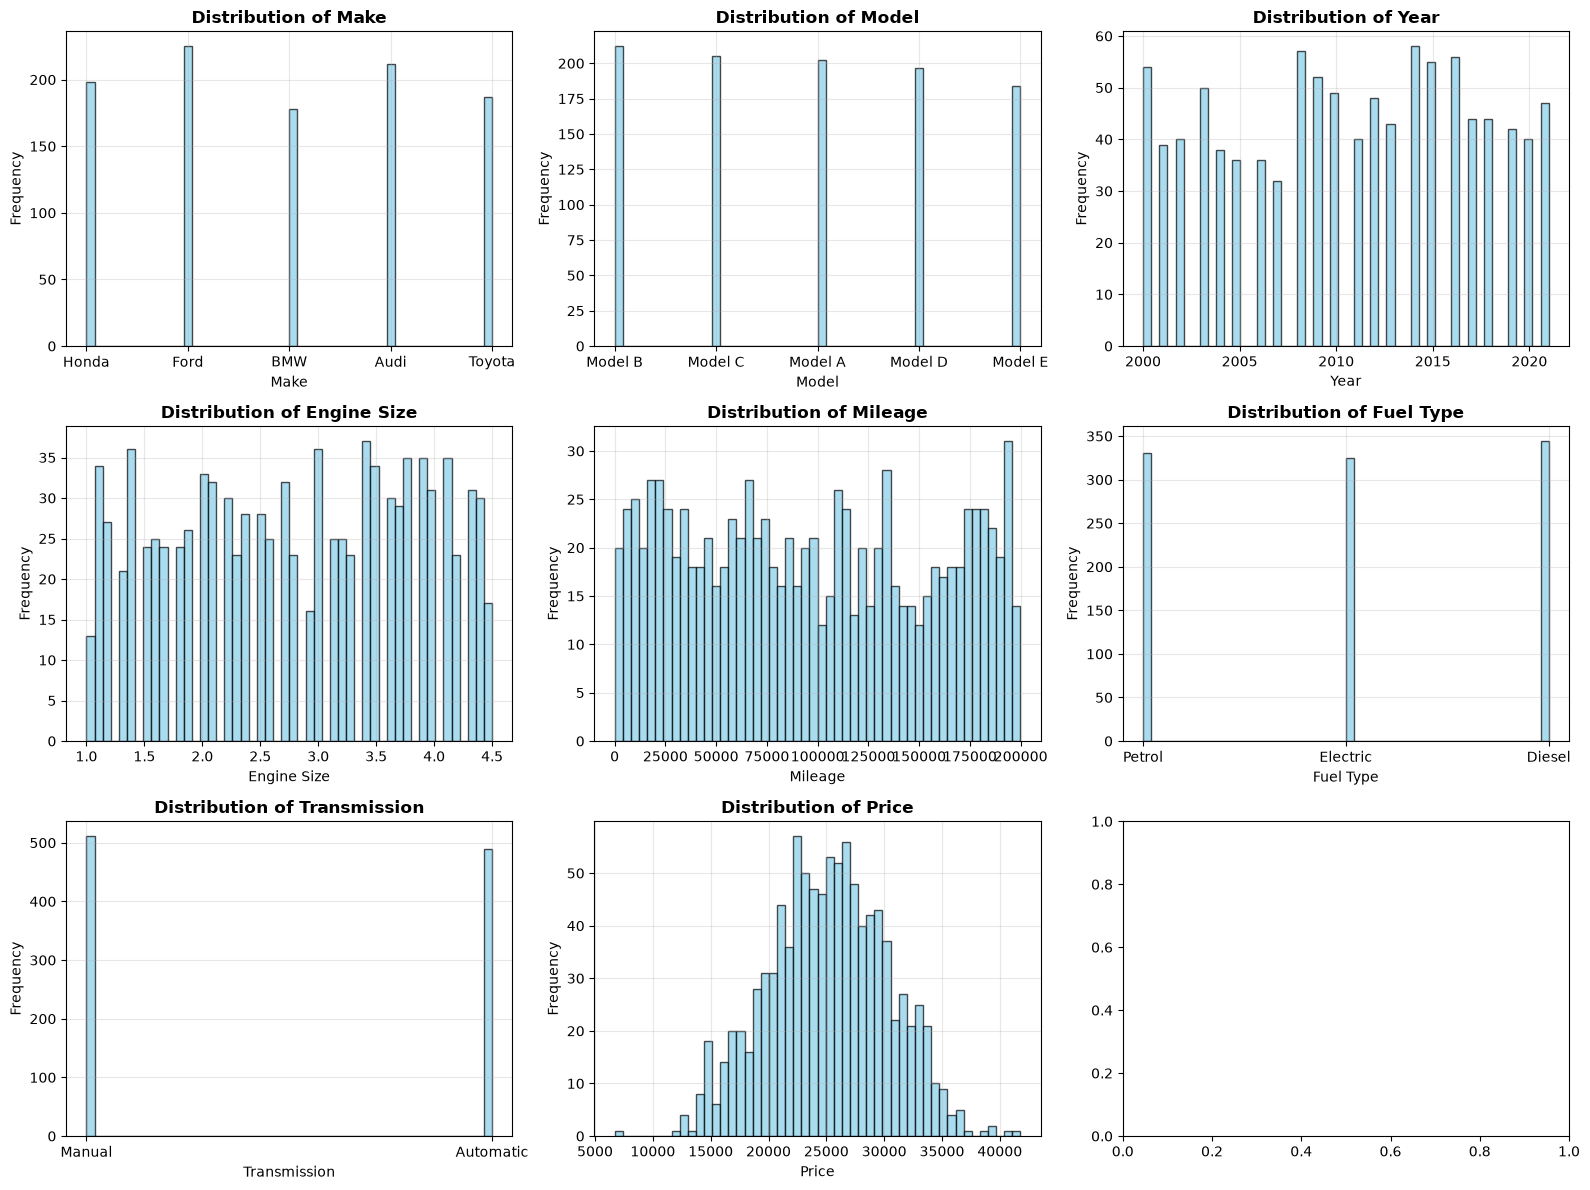

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

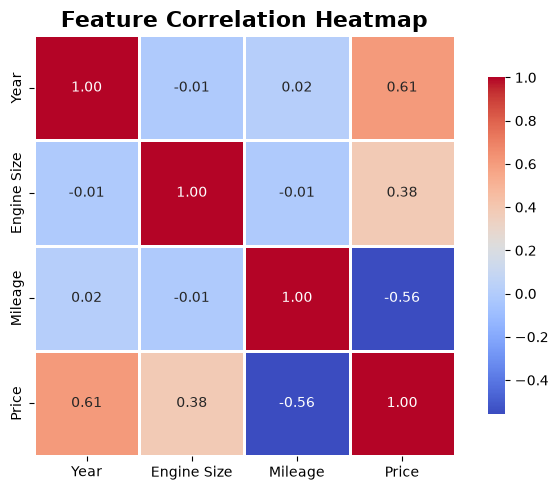

🎯 FEATURES RANKED BY CORRELATION WITH PRICE
Year              0.6096
Engine Size       0.3840
Mileage          -0.5566


In [22]:



numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()


plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


print("🎯 FEATURES RANKED BY CORRELATION WITH PRICE")

if 'Price' in correlation_matrix.columns:
    correlations = correlation_matrix['Price'].drop('Price').sort_values(ascending=False)
    for feature, corr in correlations.items():
        print(f"{feature:<15} {corr:>8.4f}")
else:
    print("❌ تنبيه: عمود 'Price' غير موجود ضمن الأعمدة الرقمية!")

In [23]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler


if not isinstance(X, pd.DataFrame):
    X = df.drop(columns=['Price'])


class AdvancedFeatureEngineer:
    def __init__(self):
        self.feature_names = []
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X_df = pd.DataFrame(X)
        else:
            X_df = X.copy()
            
        self.feature_names = list(X_df.columns)
        return X_df
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)
    
    def get_feature_names(self):
        return self.feature_names


print("📋 Actual columns in X:", list(X.columns))


numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"🔢 Numerical columns detected: {numerical_cols}")
print(f"🔤 Categorical columns detected: {categorical_cols}")


column_transformer = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)


preprocessor = Pipeline([
    ('feature_engineer', AdvancedFeatureEngineer()),
    ('transformer', column_transformer)
])


print("\n🔄 Applying preprocessing pipeline...")
X_processed = preprocessor.fit_transform(X, y)

print("✅ ADVANCED PREPROCESSING PIPELINE BUILT!")
print(f"📊 Processed data shape: {X_processed.shape}")

📋 Actual columns in X: ['Make', 'Model', 'Year', 'Engine Size', 'Mileage', 'Fuel Type', 'Transmission']
🔢 Numerical columns detected: ['Year', 'Engine Size', 'Mileage']
🔤 Categorical columns detected: ['Make', 'Model', 'Fuel Type', 'Transmission']

🔄 Applying preprocessing pipeline...
✅ ADVANCED PREPROCESSING PIPELINE BUILT!
📊 Processed data shape: (1000, 18)


In [24]:

X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=config.VAL_SIZE, random_state=config.RANDOM_STATE
)


print(f"📊 DATA SPLITS (IMPROVED from previous notebook):")
print(f"• Training: {X_train.shape[0]:,} samples (model learning)")
print(f"• Validation: {X_val.shape[0]:,} samples (hyperparameter tuning)") 
print(f"• Test: {X_test.shape[0]:,} samples (final evaluation - NEVER TOUCHED until end)")

📊 DATA SPLITS (IMPROVED from previous notebook):
• Training: 640 samples (model learning)
• Validation: 160 samples (hyperparameter tuning)
• Test: 200 samples (final evaluation - NEVER TOUCHED until end)


In [25]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    'Random Forest': RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE),  # NEW: Sequential learning
    'Support Vector Regression': SVR(),  # NEW: Different approach
}

# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")


🎯 MODEL PORTFOLIO (8 models):


In [26]:
# ===========================
# 📦 Helper 1 — Basic training and evaluation
# ===========================
def train_and_evaluate(model, X_train, y_train, X_val, y_val):
    """Train model and compute basic metrics on train and validation sets."""
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    metrics = {
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "train_r2": r2_score(y_train, y_train_pred),
        "val_r2": r2_score(y_val, y_val_pred),
        "train_mae": mean_absolute_error(y_train, y_train_pred),
        "val_mae": mean_absolute_error(y_val, y_val_pred),
        "training_time": training_time,
        "overfitting_gap": r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred) # EARLY DETECTION FOR OVERFITTING
    }

    return metrics, model

In [27]:
# ===========================
# 📦 Helper 2 — Cross-validation
# ===========================
def compute_cross_validation(model, X_train, y_train, cv_folds=config.CV_FOLDS):
    """Run cross-validation and return mean and std of R² scores."""
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv_folds, scoring='r2', n_jobs=config.N_JOBS)
    return cv_scores.mean(), cv_scores.std()

In [28]:
# ===========================
# 📦 Helper 3 — MLflow Logging
# ===========================
def log_to_mlflow(model, metrics, cv_mean, cv_std, run_name):
    """Log params, metrics, and model to MLflow in a clean, minimal way."""
    with mlflow.start_run(run_name=run_name):
        # 1. Log hyperparameters
        mlflow.log_params(model.get_params())
        
        # 2. Log main metrics
        for k, v in metrics.items():
            if k != 'training_time':  # avoid logging long times directly
                mlflow.log_metric(k, float(v))
        mlflow.log_metric("cv_r2_mean", float(cv_mean))
        mlflow.log_metric("cv_r2_std", float(cv_std))
        
        # 3. Save model artifact
        mlflow.sklearn.log_model(model, "model")

In [29]:
def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    """Train, evaluate, cross-validate, and log model in a clean step-by-step way."""
    # 1. Train and evaluate
    metrics, trained_model = train_and_evaluate(model, X_train, y_train, X_val, y_val)
    
    # 2. Cross-validation
    cv_mean, cv_std = compute_cross_validation(model, X_train, y_train)
    metrics["cv_r2_mean"] = cv_mean
    metrics["cv_r2_std"] = cv_std
    
    # 3. Log everything to MLflow
    log_to_mlflow(model, metrics, cv_mean, cv_std, model_name)
    
    return metrics, trained_model

In [30]:
import os
from pathlib import Path
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score


os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
tracking_uri = Path(config.EXPERIMENT_DIR).resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)

experiment_name = "california_housing_advanced"
mlflow.set_experiment(experiment_name)


def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    with mlflow.start_run(run_name=model_name):
        
        model.fit(X_train, y_train)
        
        
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        train_r2 = r2_score(y_train, y_train_pred)
        val_r2 = r2_score(y_val, y_val_pred)
        
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        cv_r2_mean = float(np.mean(cv_scores))
        cv_r2_std = float(np.std(cv_scores))
        
        overfitting_gap = train_r2 - val_r2
        
        metrics = {
            'train_r2': train_r2,
            'val_r2': val_r2,
            'cv_r2_mean': cv_r2_mean,
            'cv_r2_std': cv_r2_std,
            'overfitting_gap': overfitting_gap
        }
        
        mlflow.log_metrics(metrics)
        
        
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            serialization_format="cloudpickle"
        )
        
        return metrics, model


print("🚀 STARTING ADVANCED MODEL EVALUATION...")
results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    metrics, trained_model = evaluate_model_advanced(model, X_train, X_val, y_train, y_val, name)
    
    results[name] = metrics
    trained_models[name] = trained_model

    overfit_gap = metrics.get('overfitting_gap', metrics.get('train_r2', 0) - metrics.get('val_r2', 0))
    overfit_flag = "⚠️" if overfit_gap > 0.1 else "✅"
    
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} {overfit_flag}")

print("\n📈 All models trained and logged to MLflow!")
print(f"💡 Launch MLflow UI with: mlflow ui --backend-store-uri {Path(config.EXPERIMENT_DIR).resolve().as_uri()}")

🚀 STARTING ADVANCED MODEL EVALUATION...

🔧 Training Linear Regression...


2026/10/06 10:46:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:46:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Linear Regression    | Val R²: 0.8747 | CV R²: 0.8268 ± 0.0272 ✅

🔧 Training Ridge Regression...


2026/10/06 10:51:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:51:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Ridge Regression     | Val R²: 0.8744 | CV R²: 0.8269 ± 0.0270 ✅

🔧 Training Lasso Regression...


...

✅ Gradient Boosting    | Val R²: 0.8362 | CV R²: 0.7860 ± 0.0312 ✅

🔧 Training Support Vector Regression...


2026/10/06 10:52:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:52:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Support Vector Regression | Val R²: 0.0018 | CV R²: 0.0031 ± 0.0006 ✅

🔧 Training Voting Ensemble...


2026/10/06 10:52:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:52:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Voting Ensemble      | Val R²: 0.8572 | CV R²: 0.8106 ± 0.0278 ✅

📈 All models trained and logged to MLflow!
💡 Launch MLflow UI with: mlflow ui --backend-store-uri file:///C:/Users/LENOVO/sair/mohamed/SAIR_Jr/1_Regression/Regression%20Capstone%20Projects/Mohamed%20Omer/experiments


🚀 STARTING ADVANCED MODEL EVALUATION...

🔧 Training Linear Regression...


2026/10/06 10:52:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:52:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/06 10:52:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Linear Regression    | Val R²: 0.8747 | CV R²: 0.8268 ± 0.0272 ✅

🔧 Training Ridge Regression...


2026/10/06 10:52:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/06 10:52:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Ridge Regression     | Val R²: 0.8744 | CV R²: 0.8269 ± 0.0270 ✅

🔧 Training Lasso Regression...


...

2026/10/06 10:53:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:53:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Support Vector Regression | Val R²: 0.0018 | CV R²: 0.0031 ± 0.0006 ✅

🔧 Training Voting Ensemble...


2026/10/06 10:53:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:53:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Voting Ensemble      | Val R²: 0.8572 | CV R²: 0.8106 ± 0.0278 ✅

📈 All models trained and logged to MLflow!
💡 Launch MLflow UI with: mlflow ui --backend-store-uri file:///C:/Users/LENOVO/sair/mohamed/SAIR_Jr/1_Regression/Regression%20Capstone%20Projects/Mohamed%20Omer/experiments

📊 Model comparison table:


,Model,val_r2,val_rmse,val_mae,overfitting_gap,cv_r2_mean
0,Linear Regression,0.874664,1957.211516,1555.285046,-0.038345,0.826835
1,Ridge Regression,0.874367,1959.525630,1557.951416,-0.038071,0.826912
2,Lasso Regression,0.874796,1956.180648,1554.226749,-0.038480,0.827057
3,ElasticNet,0.522127,3821.690749,3111.616067,-0.005175,0.509416
4,Random Forest,0.831615,2268.566099,1802.813807,0.138048,0.782705
5,Gradient Boosting,0.836233,2237.240740,1787.141893,0.070726,0.786029
6,Support Vector Regression,0.001838,5523.316288,4456.152546,0.002783,0.003073
7,Voting Ensemble,0.857192,2089.181870,1655.263530,0.061380,0.810576


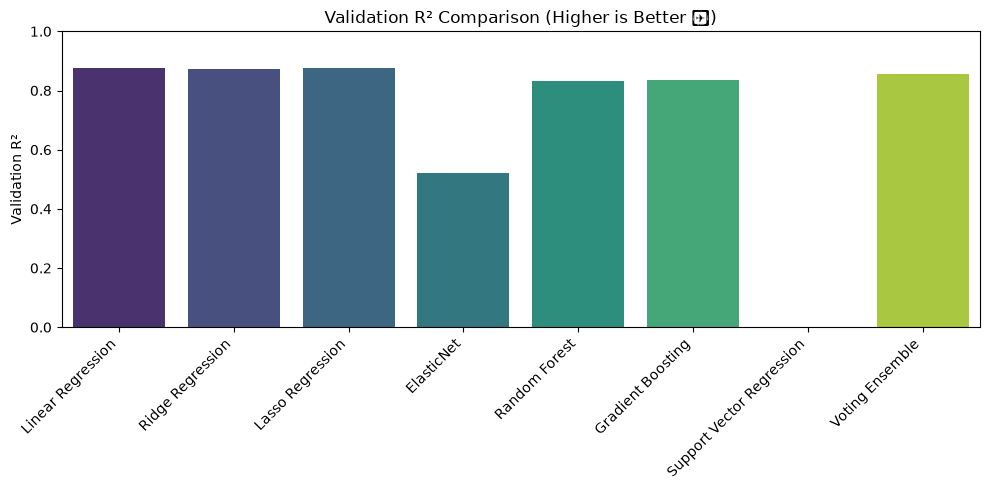

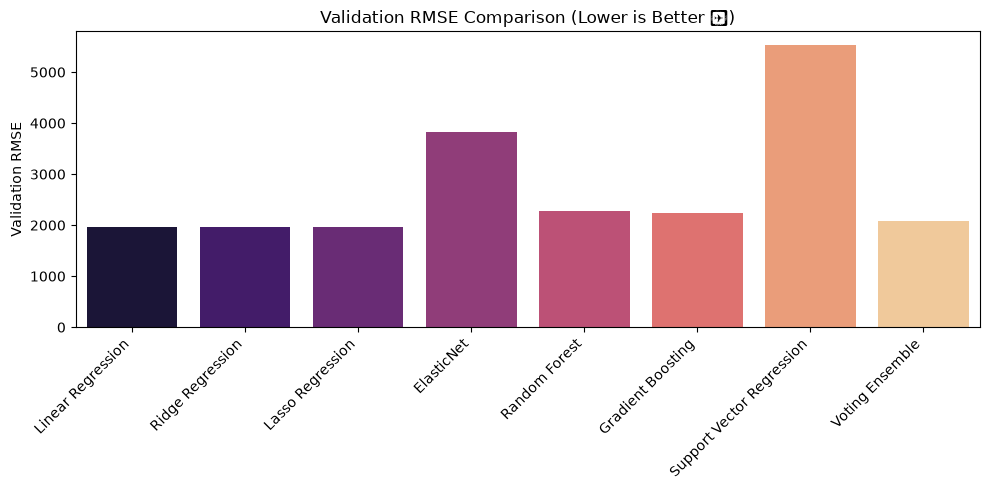

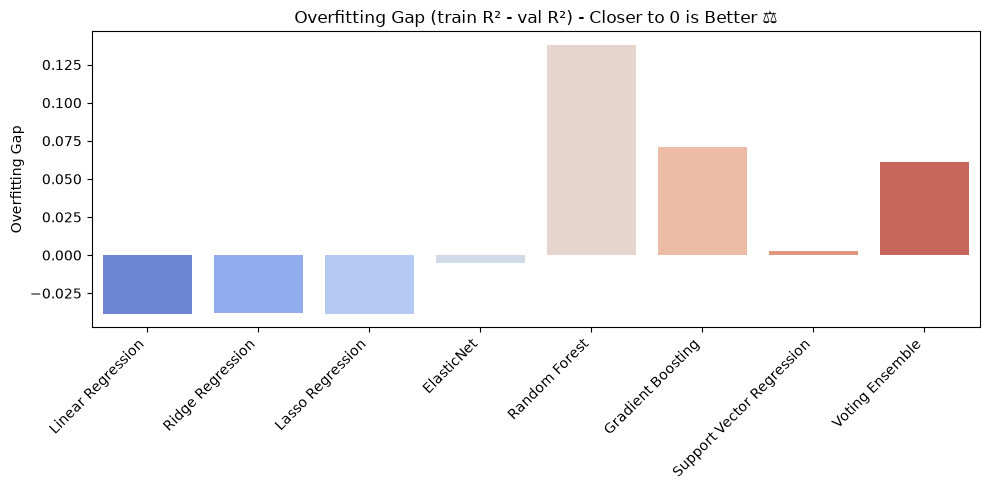

In [31]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score


os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
tracking_uri = Path(config.EXPERIMENT_DIR).resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)

experiment_name = "california_housing_advanced"
mlflow.set_experiment(experiment_name)


def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    with mlflow.start_run(run_name=model_name):
        # تدريب النموذج
        model.fit(X_train, y_train)
        
        # التنبؤ على بيانات التدريب والتحقق
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        # حساب المقاييس المطلوبة للرسم والجدول
        train_r2 = r2_score(y_train, y_train_pred)
        val_r2 = r2_score(y_val, y_val_pred)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        val_mae = mean_absolute_error(y_val, y_val_pred)
        
        # Cross Validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        cv_r2_mean = float(np.mean(cv_scores))
        cv_r2_std = float(np.std(cv_scores))
        
        overfitting_gap = train_r2 - val_r2
        
        # القاموس الشامل للمقاييس
        metrics = {
            'train_r2': float(train_r2),
            'val_r2': float(val_r2),
            'val_rmse': float(val_rmse),
            'val_mae': float(val_mae),
            'cv_r2_mean': cv_r2_mean,
            'cv_r2_std': cv_r2_std,
            'overfitting_gap': float(overfitting_gap)
        }
        
        # تسجيل المقاييس في MLflow
        mlflow.log_metrics(metrics)
        
        # حفظ النموذج بصيغة cloudpickle لمنع أخطاء skops
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            serialization_format="cloudpickle"
        )
        
        return metrics, model


print("🚀 STARTING ADVANCED MODEL EVALUATION...")
results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    metrics, trained_model = evaluate_model_advanced(model, X_train, X_val, y_train, y_val, name)
    
    results[name] = metrics
    trained_models[name] = trained_model

    overfit_gap = metrics['overfitting_gap']
    overfit_flag = "⚠️" if overfit_gap > 0.1 else "✅"
    
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} {overfit_flag}")

print("\n📈 All models trained and logged to MLflow!")
print(f"💡 Launch MLflow UI with: mlflow ui --backend-store-uri {Path(config.EXPERIMENT_DIR).resolve().as_uri()}")


metrics_df = pd.DataFrame(results).T  # transpose so models are rows
metrics_df = metrics_df[['val_r2', 'val_rmse', 'val_mae', 'overfitting_gap', 'cv_r2_mean']]
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

print("\n📊 Model comparison table:")
display(metrics_df)


plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_r2', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Validation R² Comparison (Higher is Better ✅)')
plt.ylabel('Validation R²')
plt.xlabel('')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_rmse', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Validation RMSE Comparison (Lower is Better ✅)')
plt.ylabel('Validation RMSE')
plt.xlabel('')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Overfitting Gap (train R² - val R²) - Closer to 0 is Better ⚖️')
plt.ylabel('Overfitting Gap')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [32]:
# Define comprehensive hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],  # Number of trees
        'max_depth': [None, 10, 20, 30],       # Tree depth
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'min_samples_leaf': [1, 2, 4],         # Minimum samples per leaf
        'max_features': ['auto', 'sqrt', 'log2']  # Features to consider for splits
    },
    
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],        # Number of boosting stages
        'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
        'max_depth': [3, 4, 5, 6],             # Maximum depth per tree
        'min_samples_split': [2, 5, 10],       # Minimum samples to split
        'subsample': [0.8, 0.9, 1.0]           # Fraction of samples for fitting
    },
    
    'Ridge Regression': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],  # Regularization strength
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']  # Algorithm
    },
    
    'Voting Ensemble': {
        'ridge__alpha': [0.1, 1.0, 10.0],
        'rf__n_estimators': [50, 100],
        'rf__max_depth': [10, 20],
        'gb__n_estimators': [50, 100],
        'gb__learning_rate': [0.05, 0.1]
    }
} 

In [33]:
import os
from pathlib import Path
import mlflow
import mlflow.sklearn
from sklearn.model_selection import RandomizedSearchCV


os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
if 'config' in globals() and hasattr(config, 'EXPERIMENT_DIR'):
    tracking_uri = Path(config.EXPERIMENT_DIR).resolve().as_uri()
    mlflow.set_tracking_uri(tracking_uri)

# =========================================================
# 🎯 HYPERPARAMETER OPTIMIZATION
# =========================================================
print("🎯 STARTING HYPERPARAMETER OPTIMIZATION...")
tuned_models = {}
optimization_results = {}

for model_name in ['Random Forest', 'Gradient Boosting', 'Ridge Regression', 'Voting Ensemble']:
    print(f"\n🔧 Tuning {model_name}...")
    
    with mlflow.start_run(run_name=f"{model_name}_tuned"):
        # استخدام RandomizedSearchCV للتحسين
        search = RandomizedSearchCV(
            advanced_models[model_name],
            param_grids[model_name],
            n_iter=20,  # عدد تجارب الضبط العشوائي
            cv=config.CV_FOLDS,
            scoring='r2',
            n_jobs=config.N_JOBS,
            random_state=config.RANDOM_STATE,
            verbose=1
        )
        
        
        search.fit(X_train, y_train)
        
        
        tuned_models[model_name] = search.best_estimator_
        optimization_results[model_name] = {
            'best_score': search.best_score_,
            'best_params': search.best_params_,
            'best_estimator': search.best_estimator_
        }
        
        
        mlflow.log_params(search.best_params_)
        mlflow.log_metric('best_cv_score', search.best_score_)
        
        
        mlflow.sklearn.log_model(
            sk_model=search.best_estimator_,
            artifact_path="tuned_model",
            serialization_format="cloudpickle"
        )
        
        print(f"✅ {model_name:20} | Best CV R²: {search.best_score_:.4f}")
        print(f"   Best parameters found: {search.best_params_}")

print(f"\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"💡 All tuned models saved in MLflow for comparison")

🎯 STARTING HYPERPARAMETER OPTIMIZATION...

🔧 Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/06 10:54:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:54:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest        | Best CV R²: 0.7220
   Best parameters found: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

🔧 Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/06 10:55:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:55:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Gradient Boosting    | Best CV R²: 0.7937
   Best parameters found: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 4, 'learning_rate': 0.05}

🔧 Tuning Ridge Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/06 10:55:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:55:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Ridge Regression     | Best CV R²: 0.8269
   Best parameters found: {'solver': 'sparse_cg', 'alpha': 1.0}

🔧 Tuning Voting Ensemble...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


2026/10/06 10:56:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/06 10:56:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Voting Ensemble      | Best CV R²: 0.8118
   Best parameters found: {'ridge__alpha': 0.1, 'rf__n_estimators': 100, 'rf__max_depth': 10, 'gb__n_estimators': 100, 'gb__learning_rate': 0.05}

🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!
💡 All tuned models saved in MLflow for comparison


📊 Tuned Models Performance:


,Model,Best CV R²
0,Random Forest,0.722011
1,Gradient Boosting,0.793702
2,Ridge Regression,0.826915
3,Voting Ensemble,0.811768


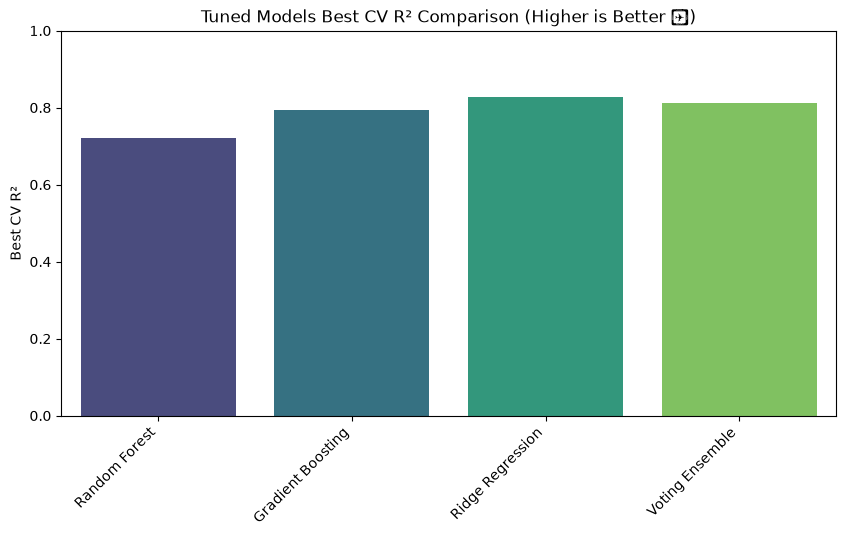

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 1️⃣ Convert optimization results to DataFrame
# ===========================
tuned_metrics_df = pd.DataFrame.from_dict({
    model: {
        'Best CV R²': optimization_results[model]['best_score']
    } for model in optimization_results
}, orient='index').reset_index().rename(columns={'index': 'Model'})

print("📊 Tuned Models Performance:")
display(tuned_metrics_df)

# ===========================
# 2️⃣ Plot Best CV R² (Higher is better)
# ===========================
plt.figure(figsize=(10,5))
sns.barplot(data=tuned_metrics_df, x='Model', y='Best CV R²', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Tuned Models Best CV R² Comparison (Higher is Better ✅)')
plt.ylabel('Best CV R²')
plt.xlabel('')
plt.ylim(0,1)
plt.show()


# A more sophisticated version of the previous visualization

Model                Untuned R²   Tuned R²     Improvement 
------------------------------------------------------------
Random Forest            0.8316     0.7447 📉  -0.0869
Gradient Boosting        0.8362     0.8386 📈   0.0024
Ridge Regression         0.8744     0.8744 📈   0.0000
Voting Ensemble          0.8572     0.8571 📉  -0.0001


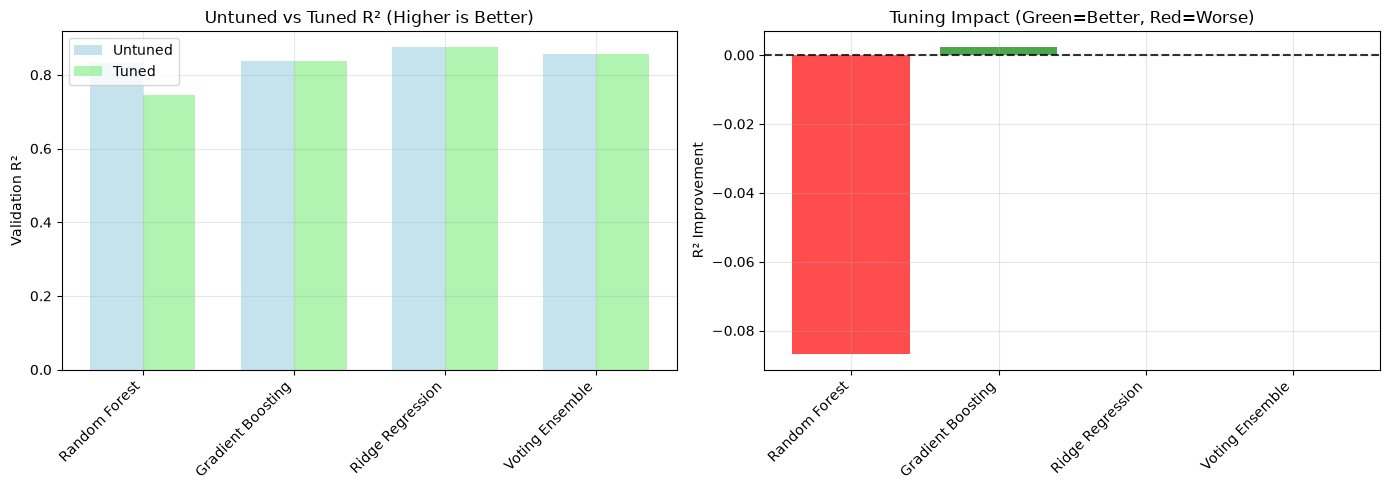


🏆 BEST TUNED MODEL: Ridge Regression
📊 Validation R²: 0.8744
📈 Improvement over untuned: +0.0000


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# ===========================
# 1️⃣ Evaluate tuned models on validation set
# ===========================
tuned_results = {}
for model_name, tuned_model in tuned_models.items():
    y_val_pred = tuned_model.predict(X_val)
    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    improvement = val_r2 - results[model_name]['val_r2']  
    
    tuned_results[model_name] = {
        'val_r2': val_r2,
        'val_rmse': val_rmse,
        'improvement': improvement
    }

# ===========================
# 2️⃣ Print simple comparison table
# ===========================
print(f"{'Model':<20} {'Untuned R²':<12} {'Tuned R²':<12} {'Improvement':<12}")
print("-" * 60)
for model_name, res in tuned_results.items():
    untuned_r2 = results[model_name]['val_r2']
    tuned_r2 = res['val_r2']
    improvement = res['improvement']
    icon = "📈" if improvement > 0 else "📉" if improvement < 0 else "➡️"
    print(f"{model_name:<20} {untuned_r2:>10.4f} {tuned_r2:>10.4f} {icon} {improvement:>8.4f}")

# ===========================
# 3️⃣ Plot Tuned vs Untuned R²
# ===========================
models = list(tuned_results.keys())
untuned_r2 = [results[m]['val_r2'] for m in models]
tuned_r2 = [tuned_results[m]['val_r2'] for m in models]
improvement = [tuned_results[m]['improvement'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# R² comparison
axes[0].bar(x - width/2, untuned_r2, width, label='Untuned', alpha=0.7, color='lightblue')
axes[0].bar(x + width/2, tuned_r2, width, label='Tuned', alpha=0.7, color='lightgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Untuned vs Tuned R² (Higher is Better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Improvement plot
colors = ['green' if i>0 else 'red' for i in improvement]
axes[1].bar(models, improvement, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.8)
axes[1].set_ylabel('R² Improvement')
axes[1].set_title('Tuning Impact (Green=Better, Red=Worse)')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===========================
# 4️⃣ Best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
print(f"\n🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")


In [36]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

best_tuned_model = tuned_models[best_model_name] 

# Predict on test set
y_test_pred = best_tuned_model.predict(X_test)

# Compute performance metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"📊 Test R²: {test_r2:.4f}")
print(f"📊 Test RMSE: {test_rmse:.4f}")
print(f"📊 Test MAE: {test_mae:.4f}")


📊 Test R²: 0.8167
📊 Test RMSE: 2239.8770
📊 Test MAE: 1810.3680


In [37]:
import os
import json
import joblib
from datetime import datetime
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# ===========================
# 0️⃣ Prepare feature names
# ===========================
# Works for both DataFrame and NumPy array
try:
    feature_names_all = list(X.columns)
except AttributeError:
    feature_names_all = [f"feature_{i}" for i in range(X.shape[1])]

# ===========================
# 1️⃣ Identify best tuned model
# ===========================
best_model_name = max(tuned_results, key=lambda m: tuned_results[m]['val_r2'])
best_tuned_model = tuned_models[best_model_name]

print(f"🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Validation R²: {tuned_results[best_model_name]['val_r2']:.4f}")
print(f"📈 Improvement over untuned: +{tuned_results[best_model_name]['improvement']:.4f}")

# ===========================
# 2️⃣ Evaluate on Test Set
# ===========================
y_test_pred = best_tuned_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n📊 Test Set Performance:")
print(f"R²: {test_r2:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")

# ===========================
# 3️⃣ Versioning and saving
# ===========================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v1_{timestamp}"
model_save_dir = os.path.join(config.MODEL_DIR, model_version)
os.makedirs(model_save_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(best_tuned_model, model_path)
print(f"✅ Model saved: {model_path}")

# Save preprocessing pipeline
preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")

# ===========================
# 4️⃣ Create model card
# ===========================
model_card = {
    'model_name': best_model_name,
    'model_version': model_version,
    'timestamp': timestamp,
    'dataset': 'Used Cars Dataset',
    'target': 'Car Price ',
    
    'performance': {
        'test_r2': float(test_r2),
        'test_rmse': float(test_rmse),
        'test_mae': float(test_mae),
        'train_r2': float(results[best_model_name]['train_r2']),
        'val_r2': float(tuned_results[best_model_name]['val_r2']),
        'cv_r2_mean': float(results[best_model_name]['cv_r2_mean']),
        'cv_r2_std': float(results[best_model_name]['cv_r2_std']),
    },
    
    'data_info': {
        'total_samples': int(len(X)),
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'n_features': X_test.shape[1],
        'feature_names': feature_names_all,
    },
    
    'model_config': {
        'model_class': best_model_name,
        'hyperparameters': dict(best_tuned_model.get_params()) 
            if hasattr(best_tuned_model, 'get_params') else {},
    },
    
    'preprocessing': {
        'steps': [
            'AdvancedFeatureEngineering (0 new features)',
            'OneHotEncoder (Categorical columns)',
            'RobustScaler (outlier-resistant scaling)',
        ],
        
    },
    
    'deployment': {
        'status': 'Ready for Production',
        'recommendations': [
            'Monitor prediction errors in production',
            'Retrain quarterly with new data',
            
        ]
    }
}

card_path = os.path.join(model_save_dir, 'model_card.json')
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2)
print(f"✅ Model card saved: {card_path}")

# ===========================
# 5️⃣ Deployment requirements
# ===========================
requirements = {
    'python': '3.8+',
    'packages': {
        'scikit-learn': '1.0+',
        'numpy': '1.20+',
        'pandas': '1.3+',
        'joblib': '1.0+',
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Deployment requirements saved: {req_path}")

# ===========================
# 6️⃣ Summary
# ===========================
print("\n💾 DEPLOYMENT PACKAGE READY")
print(f"Location: {model_save_dir}")


🏆 BEST TUNED MODEL: Ridge Regression
📊 Validation R²: 0.8744
📈 Improvement over untuned: +0.0000

📊 Test Set Performance:
R²: 0.8167 | RMSE: 2239.8770 | MAE: 1810.3680
✅ Model saved: models\v1_20261006_105626\best_model.pkl
✅ Preprocessor saved: models\v1_20261006_105626\preprocessor.pkl
✅ Model card saved: models\v1_20261006_105626\model_card.json
✅ Deployment requirements saved: models\v1_20261006_105626\requirements.json

💾 DEPLOYMENT PACKAGE READY
Location: models\v1_20261006_105626
